# 1.invoke()输入参数
标准的对话模型调用过程：  
invoke（）的输入可以是多种类型，典型的类型有：
- **1）字符串类型**
- **2）字典列表**
- **3）消息对象列表**


In [ ]:
# 非流式输出
import os
import dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
dotenv.load_dotenv()
prefix="SILICON"
chat_model = init_chat_model(
    model_provider="openai",
    configurable_fields=["model","api_key","base_url"],
    config_prefix=prefix,
).with_config({
    "configurable":{
            f"{prefix}_model":os.getenv(f"{prefix}_MODEL"),
            f"{prefix}_api_key":os.getenv(f"{prefix}_API_KEY"),
            f"{prefix}_base_url":os.getenv(f"{prefix}_BASE_URL")
    }
}

)
# 支持多个消息作为输入
messages = [
    SystemMessage(content="你是一位乐于助人的助手。你叫于老师"),
    HumanMessage(content="你是谁？")
]

response = chat_model.invoke(messages)
print(response.content)

你好！我叫于老师，是一位乐于助人的助手。请问有什么我可以帮你的吗？


## 1）字符串类型

In [3]:
from langchain.chat_models import init_chat_model
import os
import dotenv

# 加载配置文件
dotenv.load_dotenv()

SILICON_API_KEY = os.getenv("SILICON_API_KEY")
SILICON_API_BASE = os.getenv("SILICON_BASE_URL")

# 1.获取对话模型
chat_model = init_chat_model(
    api_key=SILICON_API_KEY,
    base_url=SILICON_API_BASE,
    model="openai:zai-org/GLM-5.2",
)

# 2.调用对话模型
response = chat_model.invoke("RAG 技术的核心流程，一句话字简洁总结")

# 3.处理响应数据
print(response.content)

从外部知识库**检索**相关信息作为上下文，连同用户问题一起交由大模型**生成**精准回答。


## 2）字典列表（推荐）

In [ ]:
messages=[
    {"role":"system","content":"系统提示词"}, # 设定AI的行为角色规则
    {"role":"user","content":"用户消息"},
    {"role":"assistant","content":"AI的历史回复"}, # 可选，用于对话历史
    {"role":"user","content":"继续提问"},
]

In [ ]:
# 结合大模型使用
import os
from langchain.chat_models import init_chat_model

import dotenv
dotenv.load_dotenv()

SILICON_API_KEY = os.getenv("SILICON_API_KEY")
SILICON_API_BASE = os.getenv("SILICON_BASE_URL")

model = init_chat_model(
    api_key=SILICON_API_KEY,
    base_url=SILICON_API_BASE,
    model="deepseek-ai/DeepSeek-V4-Pro",
)

messages=[
    {"role":"system","content":"你是一个专业的数学老师"},
    {"role":"user","content":"帮我介绍一下什么叫斐波那契数列"},
]

response = model.invoke(messages) # 输入消息列表
print(response.content) 
print(type(response))

### 关于多轮对话与上下文记忆

In [4]:
# 获取大模型
import os
from langchain.chat_models import init_chat_model
import dotenv
dotenv.load_dotenv()

model = init_chat_model(
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL"),
    model="deepseek-ai/DeepSeek-V4-Pro",
)

messages=[
    {"role":"system","content":"你是一个专业的数学老师"},
    {"role":"user","content":"1 + 2= ？"},
    {"role":"assistant","content":"3"}, 
    {"role":"user","content":"我刚才问了什么问题"},
]

#调用大模型，传入messages
response = chat_model.invoke(messages)

print(response.content)

你刚才问的问题是：“1 + 2= ？”


### 非同一个message同时传入，无记忆

In [5]:
message1=[
    {"role":"system","content":"你是一个非常友好的AI助手"},
    {"role":"user","content":"你好我叫小明"},
]
response1 = model.invoke(message1)
print(f"AI的回复1：{response1.content}")

message2=[
    {"role":"user","content":"我叫什么名字？"},
]

#调用大模型，传入messages
response2 = model.invoke(message2)
print(f"AI的回复2：{response2.content}")


AI的回复1：你好，小明！很高兴认识你！我是AI助手，有什么可以帮你的吗？😊
AI的回复2：很抱歉，我目前还不知道您的名字呢！因为我们才刚刚开始对话，您还没有告诉我。如果您愿意的话，可以告诉我您的名字，这样我就能更好地称呼您啦！😊


### 传递记忆

In [6]:
# 测试3
# 传递记忆
conversation = [
    {"role":"system","content":"你是一个非常友好的AI助手"},
    {"role":"user","content":"你好我叫小明"},
]

# 第一次对话
res1 = model.invoke(conversation)
print(f"AI的回复1：{res1.content}")

# 添加记忆
conversation.append({"role":"assistant","content":res1.content})
conversation.append({"role":"user","content":"我叫什么名字？"})

# 第二次对话
res2 = model.invoke(conversation)
print(f"AI的回复2：{res2.content}")

AI的回复1：你好小明！很高兴认识你～有什么我可以帮你的吗？
AI的回复2：你叫小明呀！我们刚刚才认识呢～ 😊


## 3）消息对象列表

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="我是一个人工智能助手，我的名字叫小智"),
    HumanMessage(content="人工智能英文怎么说？"),
    AIMessage(content="Artificial Intelligence"),
    HumanMessage(content="你叫什么名字？")
]

model.invoke(messages)

AIMessage(content='我叫小智。', additional_kwargs={'refusal': None, 'reasoning_content': '我们需要理解用户的问题：“人工智能英文怎么说？” 然后我回答“Artificial Intelligence”。然后用户接着问“你叫什么名字？”。所以我需要回复用户我的名字。用户第一次称呼我时提到了“我是一个人工智能助手，我的名字叫小智”，这可能是用户在设定我的身份，但实际上是用户说“我是一个人工智能助手，我的名字叫小智”，而我是AI助手，但我的身份是系统设定的。通常在这种对话中，用户可能是在测试我是否记住了他自我介绍的内容？但根据标准对话流程，用户说“我是一个人工智能助手，我的名字叫小智”，其实是用户在模仿我说话，或者说用户可能在扮演AI，然后问我人工智能英文怎么说。我回答后，他问“你叫什么名字？”。\n\n我需要考虑上下文。用户的第一句话是：“我是一个人工智能助手，我的名字叫小智”。这看起来像是用户设定了一个角色，但通常对话中，用户不会这样自我介绍，而是AI会这样介绍。可能用户是在复制一段话，或者这是测试。但无论如何，我应该根据实际情况回答：我是一个AI助手，通常是系统预设的名字，比如“我是一款人工智能助手”之类的。但在真实场景中，我是Claude，或者可能是其他。但在这个对话的上下文中，用户可能期望我回答“我叫小智”，因为用户之前说“我的名字叫小智”，但那是用户说的，不是我说的。如果用户问“你叫什么名字？”，我应该回答我自己的名字。然而在用户的第一条消息中，他说“我是一个人工智能助手，我的名字叫小智”，这可能意味着他正在扮演一个AI助手，然后问我“人工智能英文怎么说？”，我回答了相应的英文。接着他问“你叫什么名字？”，如果按照角色扮演，我可能应该回答“我叫小智”以保持一致性，因为用户可能认为他设定了一个AI叫小智，然后他作为用户来问这个AI问题。但实际上，第一句话是用户发的，内容是“我是一个人工智能助手，我的名字叫小智”，这可以理解为用户替AI做了自我介绍，然后开始提问。所以当用户问“你叫什么名字？”时，我应该回答“我叫小智”以符合前面的设定。\n\n另一种解读：用户可能只是粘贴了一段文本，然后接着提问，但通常AI助手会回答自己的名字，而不是重复用户设定的名字。不过，在多轮对话中，如果用户第一

在当次的会话中有记忆。如果是不同的messages，则没有记忆  
#### 传递记忆

In [8]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="你是一个专业的数学老师"),
    HumanMessage(content="1+3=？"),
]

# 第一次对话
response1 = model.invoke(messages)
print(f"AI的回复1：{response1.content}")

# 添加记忆
messages.append(AIMessage(content=response1.content))
messages.append(HumanMessage(content="我刚才问了什么问题？"))

# 第二次对话
response2 = model.invoke(messages)
print(f"AI的回复2：{response2.content}")

AI的回复1：1 + 3 = 4。这是一个简单的加法运算，把1和3合在一起，得到总数4。如果还有不明白的地方，可以继续问我哦！
AI的回复2：你刚才问的是：“1+3=？”  
这是一个最基础的加法问题，我们已经一起算出答案是4啦～  

如果还有其他数学问题或者想复习更多内容，随时告诉我哦！


# 2.invoke()返回值

In [10]:
# 获取大模型
import os
from langchain.chat_models import init_chat_model
import dotenv
dotenv.load_dotenv()

model = init_chat_model(
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL"),
    model="deepseek-ai/DeepSeek-V4-Pro",
    model_provider="openai"
)

response = model.invoke([HumanMessage(content="2+3=?")])

In [11]:
print(type(response))

<class 'langchain_core.messages.ai.AIMessage'>


In [12]:
print(response)

content='2 + 3 = 5.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 87, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 31, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 87}, 'model_provider': 'openai', 'model_name': 'deepseek-ai/DeepSeek-V4-Pro', 'system_fingerprint': '', 'id': '019fd5cdeb91db619b4455f5c2855f9f', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fd5cd-ef91-7930-949e-525c0a5dd41d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 87, 'output_tokens': 39, 'total_tokens': 126, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 31}}


### 美化输出

In [13]:
from rich import print as rprint

rprint(response)

AIMessage(
    content='2 + 3 = 5.',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 39,
            'prompt_tokens': 87,
            'total_tokens': 126,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 31,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 87
        },
        'model_provider': 'openai',
        'model_name': 'deepseek-ai/DeepSeek-V4-Pro',
        'system_fingerprint': '',
        'id': '019fd5cdeb91db619b4455f5c2855f9f',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019fd5cd-ef91-7930-949e-525c0a5dd41d-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 87,
        'output_tokens': 39,
        'total_tokens': 126,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 31}
    }
)

解释以下输出字段：

In [ ]:
AIMessage(
    # ---核心信息---
    content='2 + 3 = 5',   # 模型生成的最终文本答案
    additional_kwargs={'refusal': None},  # 模型拒绝回答的情况（如触碰安全策略），None表示正常回答。

    # ---响应元数据（API返回的详细原始数据）---
    response_metadata={
        'token_usage': {
            'completion_tokens': 38,
            'prompt_tokens': 87,
            'total_tokens': 125,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 31,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 87
        },
        'model_provider': 'openai',
        'model_name': 'deepseek-ai/DeepSeek-V4-Pro',
        'system_fingerprint': '',
        'id': '019fa3da0334ab0da5d2f58ff1a3f3b0',
        'finish_reason': 'stop',
        'logprobs': None
    },

    # ---LangChain内部标识---
    id='lc_run--019fa3d9-dfb4-7512-865a-4a0f42d92563-0',
    # ---LangChain追踪此条运行的唯一 ID---

    # 工具调用信息
    tool_calls=[],
    invalid_tool_calls=[],

    # 统一消耗元数据（LangChain标准化后的消耗格式）
    usage_metadata={
        'input_tokens': 87,
        'output_tokens': 38,
        'total_tokens': 125,
        'input_token_details': {'cache_read': 0},  # 命中缓存数量
        'output_token_details': {'reasoning': 31}  # 包含在输出中的推理 Token
    }
)

### 获取返回值的相关信息

In [14]:
response = model.invoke("用一句话解释什么是AI")

In [15]:
# 1 获取回复内容
print("AI回复：",response.content)

AI回复： 人工智能（AI）是让计算机系统模拟人类智能（如学习、推理、感知和决策）的科学技术。


In [16]:
# 2 获取响应元数据
metadata = response.response_metadata
print(f"使用的模型：{metadata['model_name']}")
print(f"结束原因：{metadata['finish_reason']}")
print(f"模型提供商：{metadata['model_provider']}\n")

使用的模型：deepseek-ai/DeepSeek-V4-Pro
结束原因：stop
模型提供商：openai



In [17]:
# 3 获取Token使用情况
usage = metadata.get('token_usage',{})
print(f"输入 Tokens：{usage.get('prompt_tokens')}")
print(f"输出 Tokens：{usage.get('completion_tokens')}")
print(f"总计 Tokens：{usage.get('total_tokens')}")

输入 Tokens：88
输出 Tokens：349
总计 Tokens：437


In [18]:
# 4 获取消息 ID
print(f"消息 ID:{response.id}")

消息 ID:lc_run--019fd5cf-dbc9-7523-b23f-f1141569de91-0


# 3.流式输出stream()
## 流式输出与非流式输出
invoke()非流式输出：这是Langchain与LLM交互时的默认行为，是最简单、最稳定的语言模型调用方式。  
当用户发出请求后，系统在后台等待模型生成完整响应，然后一次性将全部结果返回。

stream()流式输出：一种更具交互感的模型输出方式，用户不再需要等待完整答案，而是能看到模型逐个token 地实时返回内容。  
调用后返回一个**迭代器**，可以通过循环来实现实时处理每一个新生成的chunk内容块。

In [26]:
# 初始化模型
import os
import dotenv
from langchain.chat_models import init_chat_model
dotenv.load_dotenv(override=True)
prefix="SILICON"
model = init_chat_model(
    model_provider="openai",
    configurable_fields=["model","api_key","base_url"],
    config_prefix=prefix,
).with_config({
    "configurable":{
            f"{prefix}_model":os.getenv(f"{prefix}_MODEL"),
            f"{prefix}_api_key":os.getenv(f"{prefix}_API_KEY"),
            f"{prefix}_base_url":os.getenv(f"{prefix}_BASE_URL")
    }
})


## 流式调用LLM获取响应

In [20]:
print("开始流式输出：")
for chunk in model.stream("帮我解释一下什么是人工智能，500字以内"):
# 逐个打印内容块
    print(chunk.text, end="", flush=True)  # chunk.text或者chunk.content都可以。flush刷新缓冲区 (无换行符，缓冲区未刷新，内容可能不会立即显示)
print("\n流式输出结束")

开始流式输出：
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，旨在创造能够模拟、延伸和扩展人类智能的机器或系统。简单来说，就是**让计算机像人一样去“思考”和“学习”**。

它的核心在于赋予机器感知、推理、学习和解决问题的能力。AI并不是单一的技术，而是一个庞大的技术集合，其中最关键的两种能力是：
1. **机器学习**：让计算机通过分析海量数据自动找出规律，而不是靠人类逐条编写指令。
2. **深度学习**：模仿人类大脑神经网络的结构，处理更复杂的任务，如语音识别和图像分析。

在日常生活中，AI已经无处不在。比如智能手机里的语音助手、购物软件的个性化推荐、自动驾驶汽车，以及近期大火的ChatGPT等，都是AI的典型应用。

总而言之，目前的人工智能并不是科幻电影里拥有自我意识的机器人，而是一种强大的工具。它通过处理海量数据和复杂算法，帮助人类提高效率、突破能力边界，正在深刻改变医疗、教育、交通等各个领域。
流式输出结束


# 4.批量调用batch()  
允许一次性发送一组请求（含多条独立请求），模型会在后台并行处理，然后返回所有结果列表。  
与逐个顺序调用（invoke）相比，能大幅减少网络往返开销和等待时间，提升性能，降低成本。

### 举例1 一次性接受所有响应.batch()

In [21]:
messages = [
    "你好，你是谁？",
    "2+3*5=?",
    "中国首都在哪里？"
]
responses = model.batch(messages)

for response in responses:
    print(response)

content='你好！我是GLM，一个由Z.ai训练的大语言模型。我被设计来理解和生成人类语言，帮助回答问题、提供信息和进行各类对话交流。\n\n我的训练基于大量的文本数据，让我能够讨论各种话题，不过我也有知识边界，可能不会了解最新发生的所有事情。\n\n有什么我能帮你解答的问题或者你想聊的话题吗？' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 232, 'prompt_tokens': 17, 'total_tokens': 249, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 159, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'openai', 'model_name': 'zai-org/GLM-5.2', 'system_fingerprint': '', 'id': '019fd5d619965e06af10539d7d53d681', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fd5d6-1ca6-79a2-960d-0ccbe57e5401-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 17, 'output_tokens': 232, 'total_tokens': 249, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 159}}
c

### 举例2：按照完成的顺序接受响应 .batch_as_completed()

In [22]:
messages = [
    "你好，你是谁？",
    "2+3*5=?",
    "中国首都在哪里？"
]
responses = model.batch_as_completed(messages)

for response in responses:
    print(response)

(2, AIMessage(content='中国的首都是**北京**。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 17, 'total_tokens': 135, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 111, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'openai', 'model_name': 'zai-org/GLM-5.2', 'system_fingerprint': '', 'id': '019fd5d6ec3f3f12f800e4ec65b45be2', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd5d6-ef6d-7280-bffe-a173354f6dbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 118, 'total_tokens': 135, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 111}}))
(1, AIMessage(content='The answer is **17**. \n\nAccording to the order of operations (PEMDAS/BODMAS), you d

### 举例3：batch和循环invoke性能对比

使用batch：

In [28]:
# 准备多个输入
inputs = [
    "翻译成英文：春天来了",
    "翻译成英文：夏天很热",
    "翻译成英文：秋天落叶",
    "翻译成英文：冬天下雪",
]

# 批量调用（高效）
import time

start = time.time()
responses = model.batch(inputs)
batch_time = time.time() - start

print("批量调用结果：")
for i,response in enumerate(responses):
    print(f"{i+1}.{response.content}")
print(f"耗时：{batch_time:.2f}秒\n")

批量调用结果：
1.Spring has come.
2.Summer is very hot.
3.Autumn leaves.
4.It snows in winter.
耗时：16.82秒



作为对比，演示循环调用invoke()：

In [29]:
# 准备多个输入
inputs = [
    "翻译成英文：春天来了",
    "翻译成英文：夏天很热",
    "翻译成英文：秋天落叶",
    "翻译成英文：冬天下雪",
]

# 循环调用invoke
import time

start = time.time()
loop_responses = []
for inp in inputs:
    response = model.invoke(inp)
    loop_responses.append(response)
loop_time = time.time() - start

for i, response in enumerate(loop_responses):
    print(f"{i+1}.{response.content}")

print(f"循环调用耗时：{loop_time:.2f}秒\n")
print(f"批量调用节省时间：{((loop_time - batch_time)/loop_time * 100):.1f}%")

1.Spring is coming.
2.Summer is very hot.
3.Autumn leaves falling.
4.It snows in winter.
循环调用耗时：33.00秒

批量调用节省时间：49.0%


### 举例4：消息对象列表batch

In [30]:
import os
import dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
dotenv.load_dotenv()

# 初始化大模型
chat_model = init_chat_model(
    model="deepseek-ai/DeepSeek-V4-Pro",
    model_provider="openai",
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL")
)

messages1 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
    HumanMessage(content="请帮我一句话介绍一下什么是机器学习"), ]
messages2 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
    HumanMessage(content="请帮我一句话介绍一下什么是AIGC"), ]
messages3 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
    HumanMessage(content="请帮我一句话介绍一下什么是大模型技术"), ]
messages = [messages1, messages2, messages3]
# 调用batch
responses = chat_model.batch(messages)
# print(response[0].content)
# print(response[1].content)
# print(response[2].content)

for response in responses:
    print(response.content)

机器学习是让计算机从数据中自动学习模式并做出预测或决策，而无需明确编程的一种人工智能技术。
AIGC是人工智能生成内容（AI Generated Content）的简称，指利用人工智能技术自动创作文本、图像、音频、视频等数字内容的新型生产方式。
大模型技术是指基于海量数据和巨大参数规模训练的深度学习模型，能够理解和生成自然语言、图像等内容，实现多种复杂智能任务。


# 5.同步调用与异步调用

**同步（sync）**  
发起一个任务后，需要等该任务完成后，才能继续执行后续任务。  
- invoke()
- stream()
- batch()

**异步（async）**  
发起一个任务后，不必等该任务完成，可以继续执行其他任务。  
- ainvoke()
- astream()
- abatch()

### 1）同步调用

In [31]:
# 同步调用
import time
def call_model():
# 模拟同步API调用
    print("开始调用模型...")
    time.sleep(5) # 模拟调用等待,单位：秒
print("模型调用完成。")
def perform_other_tasks():
# 模拟执行其他任务
    for i in range(5):
        print(f"执行其他任务 {i + 1}")
        time.sleep(1) # 单位：秒
def main():
    start_time = time.time()
    call_model()
    perform_other_tasks()
    end_time = time.time()
    total_time = end_time - start_time
    return f"总共耗时：{total_time}秒"
# 运行同步任务并打印完成时间
main_time = main()
print(main_time)

模型调用完成。
开始调用模型...
执行其他任务 1
执行其他任务 2
执行其他任务 3
执行其他任务 4
执行其他任务 5
总共耗时：10.004156827926636秒


之前的llm.invoke(...) 本质上是一个同步调用。每个操作依次执行，直到当前操作完成后才开始下一个
操作，从而导致总的执行时间是各个操作时间的总和。

### 2）异步调用  
异步调用，允许程序在等待某些操作完成时继续执行其他任务，而不是阻塞等待。这在处理I/O操作（如
网络请求、文件读写等）时特别有用，可以显著提高程序的效率和响应性。

In [ ]:
# 写法1：此写法适合Jupyter Notebook
import asyncio
import time
async def async_call(llm):
    await asyncio.sleep(5) # 模拟异步操作
    print("异步调用完成")

async def perform_other_tasks():
    await asyncio.sleep(5) # 模拟异步操作
    print("其他任务完成")

async def run_async_tasks():
    start_time = time.time()
    await asyncio.gather(
        async_call(None), # 示例调用，使用None模拟LLM对象
        perform_other_tasks()
    )
    end_time = time.time()
    return f"总共耗时：{end_time - start_time}秒"
# # 正确运行异步任务的方式  py文件中
# if __name__ == "__main__":
# # 使用 asyncio.run() 来启动异步程序
# result = asyncio.run(run_async_tasks())
# print(result)

# 在 Jupyter 单元格中直接调用
result = await run_async_tasks()
print(result)

异步调用完成
其他任务完成
总共耗时：5.015366315841675秒


**说明：**   
使用asyncio.gather() 并行执行时，理想情况下，因为两个任务几乎同时开始，它们的执行时间将重
叠。如果两个任务的执行时间相同（这里都是5秒），那么总执行时间应该接近单个任务的执行时间，而
不是两者时间之和。

一个判断是不是异步的方式：

In [33]:
# 验证ainvoke是否是异步

# 方式1
import inspect
print("ainvoke 是协程函数:", inspect.iscoroutinefunction(chat_model.ainvoke))
print("invoke 是协程函数:", inspect.iscoroutinefunction(chat_model.invoke))

ainvoke 是协程函数: True
invoke 是协程函数: False


#### 举例1：异步ainvoke()

In [34]:
import asyncio
import os
import time
import dotenv
from langchain.chat_models import init_chat_model

# 加载环境变量
dotenv.load_dotenv()
prefix = "SILICON"
# 初始化大模型
try:
    chat_model = init_chat_model(
        model_provider="openai",
        configurable_fields=["model","api_key","base_url"],
        config_prefix=prefix,
    ).with_config({
        "configurable":{
            f"{prefix}_model":os.getenv(f"{prefix}_MODEL"),
            f"{prefix}_api_key":os.getenv(f"{prefix}_API_KEY"),
            f"{prefix}_base_url":os.getenv(f"{prefix}_BASE_URL"),            
        }
    })
    print(f"LLM初始化成功！")
except Exception as e:
    print(f"LLM初始化失败，失败原因：{e}")
    chat_model=None

# 同步调用（对比组）
async def demo_async_invoke():
    print("+++演示：ainvoke 的异步（非阻塞）效果+++")
    start_time = time.perf_counter()  # 记录开始时间

    print("程序开始...")

    # 1. 创建任务（task）
    print(">>>发起异步模型调用（ainvoke）...")
    async_task = asyncio.create_task(chat_model.ainvoke("用一句话解释人工智能。"))

    # 2. 并行执行其他任务
    print(">>>模型请求已在后台发送，继续执行本地逻辑...")
    for i in range(3):
        await asyncio.sleep(1)  # 异步等待，释放控制权
        print(f">>>正在执行第{i+1}个任务...(已耗时{time.perf_counter() - start_time:.2f}s)")

    # 3. 获取模型结果
    print(">>>本地任务完成，检查模型状态...")
    response = await async_task

    end_time = time.perf_counter()
    print(f">>>模型返回：{response.content}")
    print(f"++++总运行耗时：{end_time- start_time:.2f}s+++++")

# 入口：执行异步主函数
# if __name__ == "__main__":
#     asyncio.run(demo_async_invoke())  # py文件这么写

# asyncio.run() 在 ipynb 直接顶层调用冲突
# Jupyter Notebook 本身已经运行在一个 asyncio 事件循环里
await demo_async_invoke()   


LLM初始化成功！
+++演示：ainvoke 的异步（非阻塞）效果+++
程序开始...
>>>发起异步模型调用（ainvoke）...
>>>模型请求已在后台发送，继续执行本地逻辑...
>>>正在执行第1个任务...(已耗时1.00s)
>>>正在执行第2个任务...(已耗时2.02s)
>>>正在执行第3个任务...(已耗时3.03s)
>>>本地任务完成，检查模型状态...
>>>模型返回：人工智能是使计算机系统能够模拟人类智能行为（如学习、推理、感知和决策）从而执行通常需要人类智慧才能完成的任务的科学与工程。
++++总运行耗时：6.48s+++++


#### 举例2：异步astream()

In [35]:
import asyncio
import os
import time
import dotenv
from langchain.chat_models import init_chat_model

# 加载环境变量
dotenv.load_dotenv()
prefix = "SILICON"
# 初始化大模型
try:
    chat_model = init_chat_model(
        model_provider="openai",
        configurable_fields=["model","api_key","base_url"],
        config_prefix=prefix,
    ).with_config({
        "configurable":{
            f"{prefix}_model":os.getenv(f"{prefix}_MODEL"),
            f"{prefix}_api_key":os.getenv(f"{prefix}_API_KEY"),
            f"{prefix}_base_url":os.getenv(f"{prefix}_BASE_URL"),            
        }
    })
    print(f"LLM初始化成功！")
except Exception as e:
    print(f"LLM初始化失败，失败原因：{e}")
    chat_model=None

# 同步调用（对比组）
async def demo_async_stream():
    print("+++演示：astream 的异步（非阻塞）效果+++")
    start_time = time.perf_counter()  # 记录开始时间
    print("程序开始...")

    # 1. 发起异步流式请求
    # 注意：此时请求已发出，返回的是一个异步生产器
    print(">>>发起异步模型调用（astream）...")
    stream_resp = chat_model.astream("请用一句话解释人工智能。")

    # 2. 在等待流式响应的同时，执行其他任务
    print(">>>流式请求已发送，程序无需等待，继续执行其他异步任务...")
    for i in range(3):
        # 使用 asyncio.sleep而非time.sleep
        # 这允许事件循环在等待时去处理上面的stream_resp网络 IO
        await asyncio.sleep(1)  # 异步等待，释放控制权
        print(f">>>正在执行第{i+1}个任务...(已耗时{time.perf_counter() - start_time:.2f}s)")

    # 3. 现在开始处理流式结果
    print(">>>模拟任务已完成，开始读取缓冲区的流式结果...")
    end_time = time.perf_counter()
    print(f">>>流式输出：",end="",flush=True)
    async for chunk in stream_resp:
        content=chunk.content if hasattr(chunk, 'content') else str(chunk)
        print(content, end="", flush=True)

    print("\n流式输出结束\n")
    print(f"++++总运行耗时：{end_time- start_time:.2f}s+++++")

# 入口：执行异步主函数
# if __name__ == "__main__":
#     asyncio.run(demo_async_stream())

await demo_async_stream()

LLM初始化成功！
+++演示：astream 的异步（非阻塞）效果+++
程序开始...
>>>发起异步模型调用（astream）...
>>>流式请求已发送，程序无需等待，继续执行其他异步任务...
>>>正在执行第1个任务...(已耗时1.01s)
>>>正在执行第2个任务...(已耗时2.02s)
>>>正在执行第3个任务...(已耗时3.02s)
>>>模拟任务已完成，开始读取缓冲区的流式结果...
>>>流式输出：人工智能是研究、开发用于模拟、延伸和扩展人类智能的理论、方法、技术及应用系统的一门新的技术科学。
流式输出结束

++++总运行耗时：3.02s+++++


#### 举例3：异步abatch()

In [36]:
import asyncio
import os
import time
import dotenv
from langchain.chat_models import init_chat_model

# 加载环境变量
dotenv.load_dotenv()
prefix = "SILICON"
# 初始化大模型
try:
    chat_model = init_chat_model(
        model_provider="openai",
        configurable_fields=["model","api_key","base_url"],
        config_prefix=prefix,
    ).with_config({
        "configurable":{
            f"{prefix}_model":os.getenv(f"{prefix}_MODEL"),
            f"{prefix}_api_key":os.getenv(f"{prefix}_API_KEY"),
            f"{prefix}_base_url":os.getenv(f"{prefix}_BASE_URL"),            
        }
    })
    print(f"LLM初始化成功！")
except Exception as e:
    print(f"LLM初始化失败，失败原因：{e}")
    chat_model=None

questions = [
    "用一句话介绍机器学",
    "中国的首都在哪里",
    "上海的简称是什么"
]

# 同步调用（对比组）
async def demo_async_batch():
    print("+++演示：abatch 的异步（非阻塞）效果+++")
    start_time = time.perf_counter()  # 记录开始时间
    print("程序开始...")

    # 1. 发起异步批量请求
    # 关键修改：使用 create_task 让协程立即在后台执行
    print(">>>发起异步批量调用（abatch）...")
    batch_task = asyncio.create_task(chat_model.abatch(questions))

    # 2. 在等待批量处理的同时，执行其他任务
    print(">>>批量任务已在后台运行，主程序无需等待，继续执行其他任务...")
    for i in range(3):
        # 使用 asyncio.sleep允许后台任务获取 CPU 时间片进行网络请求
        await asyncio.sleep(1)  # 异步等待，释放控制权
        print(f">>>正在执行第{i+1}个任务...(已耗时{time.perf_counter() - start_time:.2f}s)")

    # 3. 等待批量处理结果
    print(">>>其他任务已完成，现在获取后台批量任务的结果...")
    # 此时 batch_task 可能已经完成，或者我们在这里等它完成
    responses = await batch_task
    
    end_time = time.perf_counter()

    for response in responses:
        content=response.content if hasattr(response, 'content') else str(response)
        print(f">>>响应内容：{content}")

    print(f"++++总运行耗时：{end_time- start_time:.2f}s+++++")

# 入口：执行异步主函数
# if __name__ == "__main__":
#     asyncio.run(demo_async_batch())

await demo_async_batch()

LLM初始化成功！
+++演示：abatch 的异步（非阻塞）效果+++
程序开始...
>>>发起异步批量调用（abatch）...
>>>批量任务已在后台运行，主程序无需等待，继续执行其他任务...
>>>正在执行第1个任务...(已耗时1.01s)
>>>正在执行第2个任务...(已耗时2.02s)
>>>正在执行第3个任务...(已耗时3.04s)
>>>其他任务已完成，现在获取后台批量任务的结果...
>>>响应内容：机器学习是人工智能的一个分支，研究如何让计算机通过数据自动学习和改进，无需明确编程。
>>>响应内容：中国的首都是**北京**。
>>>响应内容：上海的简称是“沪”。此外，上海也有“申”这一别称，来源于战国时期春申君的封地。
++++总运行耗时：33.10s+++++


### 3）判断什么时候用什么调用方式
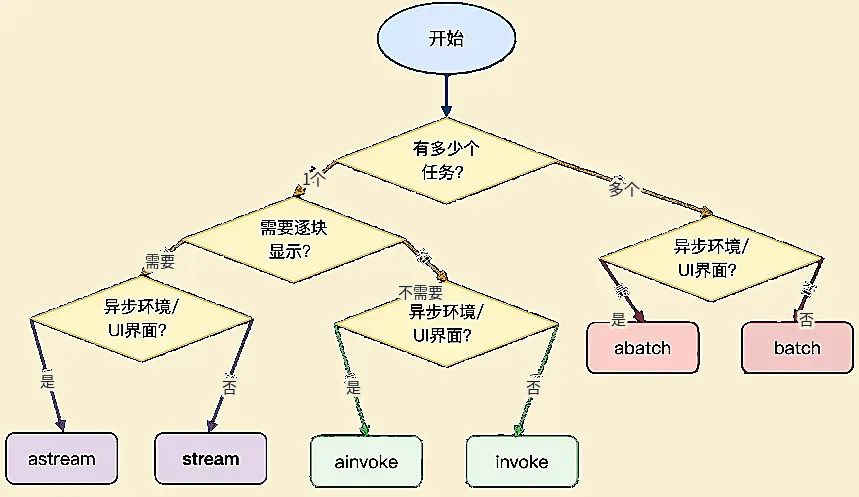

# 6.拓展知识

## 1）输出美化  
用rich库，from rich import print as rrprint

## 2) 模型的profile属性的使用
### 举例1：DeepSeek官网模型能力画像--无

In [37]:
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6
)

print(model.profile)

{}


### 举例2：SILICON平台模型能力画像--无

In [38]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = ChatOpenAI(
    model="Pro/MiniMaxAI/MiniMax-M2.5",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL")
)

print(model.profile)

{}


### 举例3：Opentouter平台模型能力画像

从openrouter平台找一个免费模型：openai/gpt-oss-20b:free  
google/gemma-4-31b-it:free

In [40]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from rich import print as rprint
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL")
)

rprint(model.profile)

{
    'name': 'gpt-oss-20b (free)',
    'release_date': '2025-08-05',
    'last_updated': '2025-08-05',
    'open_weights': True,
    'max_input_tokens': 131072,
    'max_output_tokens': 32768,
    'text_inputs': True,
    'image_inputs': False,
    'audio_inputs': False,
    'video_inputs': False,
    'text_outputs': True,
    'image_outputs': False,
    'audio_outputs': False,
    'video_outputs': False,
    'reasoning_output': True,
    'tool_calling': True,
    'structured_output': True,
    'attachment': False,
    'temperature': True,
    'tool_call_streaming': True
}

In [41]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from rich import print as rprint
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = ChatOpenRouter(
    model="google/gemma-4-31b-it:free",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL")
)

rprint(model.profile)

{
    'name': 'Gemma 4 31B (free)',
    'release_date': '2026-04-02',
    'last_updated': '2026-04-02',
    'open_weights': True,
    'max_input_tokens': 262144,
    'max_output_tokens': 32768,
    'text_inputs': True,
    'image_inputs': True,
    'audio_inputs': False,
    'video_inputs': True,
    'text_outputs': True,
    'image_outputs': False,
    'audio_outputs': False,
    'video_outputs': False,
    'reasoning_output': True,
    'tool_calling': True,
    'structured_output': False,
    'attachment': True,
    'temperature': True,
    'tool_call_streaming': True
}

# 7.模型初始化参数（完整版）
## 1）初始化参数

### 举例1：ChatDeepSeek()\ChatOpenAI()

In [43]:
from langchain_deepseek import ChatDeepSeek

rprint(ChatDeepSeek.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 
'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 
'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 
'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 
'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning',
'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 'stop',
'extra_body', 'include_response_headers', 'disabled_params', 'include', 'service_tier', 'store', 'truncation', 
'use_previous_response_id', 'use_responses_api', 'api_key', 'api_base'])

In [44]:
from langchain_openai import ChatOpenAI

rprint(ChatOpenAI.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 
'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 
'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 
'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 
'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning',
'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 'stop',
'extra_body', 'include_response_headers', 'disabled_params', 'include', 'service_tier', 'store', 'truncation', 
'use_previous_response_id', 'use_responses_api'])

### 举例2：init_chat_model()

In [45]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model_provider="deepseek",
    model="deepseek-v4-flash",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

print(model.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning', 'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 'stop', 'extra_body', 'include_response_headers', 'disabled_params', 'include', 'service_tier', 'store', 'truncation', 'use_previous_response_id', 'use_responses_api', 'api_key', 'api_base'])


C:\Users\huan.zheng\AppData\Local\Temp\ipykernel_25700\279488173.py:18: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  print(model.model_fields.keys())


这个结果和ChatDeepSeek()是一致的。

## 2）dict_keys中的几类参数
### (1) 客户端与连接参数（Networking）  
这类参数决定了代码“怎么连接到服务端”，而不是让模型怎么生成  
| 参数名 | 说明 |
| ---- | ---- |
| api_key / openai_api_key | 鉴权密钥。DeepSeek 通常兼容 OpenAI 接口格式。 |
| api_base / openai_api_base | 接口地址（如 https://api.deepseek.com）。 |
| request_timeout | 网络请求超时时间。 |
| max_retries | 请求失败时的重试次数。 |
| http_client / http_async_client | 手动传入 httpx.Client 实例（用于更复杂的网络配置）。 |
| openai_proxy | 代理服务器配置。 |
| default_headers / default_query | 每次请求时默认携带的 HTTP Header 或 Query 参数。 |

### (2) 模型推理参数（Model Inference）
这类是直接传递给DeepSeek模型API的参数，决定了生成质量和风格  
| 参数名 | 说明 |
| ---- | ---- | 
| model_name | 指定具体模型（如deepseek-chat 或 deepseek-reasoning） |  
| temperature | 采样温度，越高越随机 |
| top_p | 核采样参数 |  
| max_tokens | 最大输出token数 |
| stop | 停止符列表 |
| streaming | 是否开启流式输出 |
| n | 生成几个候选回复 |
| reasoning | 是否启用推理模式 |
| reasoning_effort | (deepseek R1特有)控制思考链（COT）深度 | 
| presence_penalty / frequency_penalty | 惩罚项（存在惩罚、频率惩罚），用于减少内容重复 |
| store | 是否存储对话 |
| logit_bias | 调整特定词汇出现的概率 |

### (3) LangChain框架通用的参数
由LangChain的BaseChatModel 定义的。所有子类 Chatxxx都具备。  
用于管理 LangChain 内部的逻辑（如日志、回调、元数据），仅在内部生效  
| 参数名 | 说明 |
| ---- | ---- | 
| name | 给模型实例起个名字，用于在Trace（如LangSmith）中区分 |  
| verbose | 是否打印详细日志 |
| callbacks | 回调处理器。用于集成LangSmith或自定义监控 |  
| tags / metadata | 用于标记该实例的标签和元数据 | 
| cache | 是否缓存该模型的请求结果 | 
| rate_limiter | LangChain 内部的频率限制器 |

### (4) 高级与特定扩展参数 
常用于特定场景，或为了保持与OpenAI协议的兼容性而存在  
- 底层客户端访问：client,async_client,root_client.  
- 透传参数：**model_kwargs,extra_body**(如果你想传递DeepSeek API支持但LangChain还没定义的参数，可以写在这)  
- 功能开关：disable_streaming,include_response_headers (决定是否在输出中包含Header)  
- 兼容性参数： openai_organization,service_tier,store(OpenAI遗留，DS实际很少用)

#### model_kwargs  
**用于存放OpenAI Compatible API支持，但LangChain没有直接列出的字段**  

例如用于funciton call的tools字段

In [46]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    model_kwargs={"tools":[
        {
            "type": "function",
            "function":{
                "name":"get_weather",
                "description":"Get weather of a location, the user should supply a location first.",
                "parameters": {
                    "type":"object",
                    "properties":{
                        "location":{
                            "type":"string",
                            "description":"The city and state, e.g. San Francisco, CA",
                        }
                    },
                    "required":["location"]
                }
            }
        }
    ]}
)

response = model.invoke("你好，今天上海的天气如何？")  # tool_calls=非空
rprint(response)

response1 = model.invoke("一句话介绍AI") # 不会使用工具 tool_calls=[]
rprint(response1)


AIMessage(
    content='',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': 'The user asks about the weather in Shanghai today. I should get weather for Shanghai.
The user wrote in Chinese, so I should respond in Chinese. Let me call the weather tool.'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 82,
            'prompt_tokens': 383,
            'total_tokens': 465,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 37,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 383
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
        'id': '901e4617-8ed6-4681-a88a-fce2aee043d8',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019fd606-bd66-7c13-862f-4e346f9bef73-0',
    tool_calls=[
        {
            'name': 'get_weather',
            'args': {'location': '上海'},
            'id': 'call_00_2aAAtUyEq2LVMfDBI5Rq4431',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 383,
        'output_tokens': 82,
        'total_tokens': 465,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 37}
    }
)

AIMessage(
    content='人工智能（AI）是让计算机模拟人类智能，从而自主完成学习、推理、感知和决策等任务的科学技术。',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': 'The user asks for a one-sentence introduction of AI in Chinese. No tools needed.'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 44,
            'prompt_tokens': 379,
            'total_tokens': 423,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 18,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
            'prompt_cache_hit_tokens': 256,
            'prompt_cache_miss_tokens': 123
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
        'id': '5fc4fa94-c164-4cf2-b7e4-a05c1fa8432b',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019fd606-c132-72f1-8d0b-278fa2ffaf76-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 379,
        'output_tokens': 44,
        'total_tokens': 423,
        'input_token_details': {'cache_read': 256},
        'output_token_details': {'reasoning': 18}
    }
)

#### extra_body  
**用于存放模型厂商基于OpenAI API协议扩展字段**   
 
例如deepseek的thinking用于控制是否启用思考模式，OpenAI是没有的。

In [47]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    extra_body={"thinking":{"type":"enabled"}},
    # extra_body={"thinking":{"type":"disabled"}},
)

response = model.invoke("你好，一句话回答") 
rprint(response)


AIMessage(
    content='你好！有什么可以一句话帮到你的？',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': 
'我们只需要一句话回答。用户说“你好，一句话回答”，可能期待我们简短回应。我们应回一句话。'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 34,
            'prompt_tokens': 87,
            'total_tokens': 121,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 24,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 87
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
        'id': 'c019cfc2-18fb-49a5-bd8f-2d05c5a155fb',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019fd608-5f50-7840-9d03-039184e9443d-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 87,
        'output_tokens': 34,
        'total_tokens': 121,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 24}
    }
)

### (5) 需要记住哪些参数？
- 客户端与连接参数（Networking）  
- model_kwargs和extra_body要了解，可查文档

# 8.模型调用（invoke、stream、batch等）中的config参数

config参数：允许在调用模型时，动态配置和控制模型的行为  
config中支持配置的参数如下

| 配置项           | 类型                      | 描述                                                                                                 |
| ---------------- | ------------------------- | ---------------------------------------------------------------------------------------------------- |
| run_name         | str                       | 为当前运行设置一个可读的名称。如在LangSmith追踪系统中快速定位和识别不同的运行任务。|
| tags             | List[str]                 | 为运行设置标签，用于分类和过滤。如在LangSmith追踪系统中快速定位和识别不同的运行任务。|
| callbacks        | List[BaseCallbackHandler] | 设置回调处理器，在运行的不同阶段（开始、流输出、结束等）触发。与一些监控平台（如LangSmith）集成进行深度追踪和调试。 |
| metadata         | Dict[str,Any]             | 附加任意的键值对元数据。记录本次调用的业务上下文，如{"user_id": "123", "session_id": "abc"}          |
| max_concurrency  | int                       | 限制当前可运行对象的最大并发运行数。防止对API接口或本地资源造成过大压力，实现简单的速率限制。|
| recursion_limit  | int                       | 限制运行时递归调用的最大深度。主要在复杂的工作流（如Agent执行多步工具调用）中，防止出现无限递归循环。 |
| configurable     | Dict[Str,Any]             | 一个万能字典，用于传递其他可配置参数。实现更高级的动态行为，如配置可替代的模型或组件。|


config参数中 run_name、tags、callbacks主要用在LangSmith中，用于追踪、筛选、和调试

metadata可以配置用户指定的一些信息，在工作流开发中，当整个流程被包装为Runnable链时，可以将这些参数传递给后续链节点使用

configurable中可配置的参数与init_chat_model初始化模型参数一样。与在初始化模型时设置的参数关键区别在于：
- init_chat_model初始化参数：模型的默认设置，使用于该模型实例的大部分场景 
- 运行时config：单次调用的特定设置，优先级更高，针对本次调用进行的特殊调整。

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from rich import print as rprint

load_dotenv()

llm = init_chat_model(
    model="zai-org/GLM-5.2",
    model_provider="openai",
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL"),
    temperature=0.5,
    max_tokens=200,
    # 指定可调整的参数
    configurable_fields=["model","model_provider","temperature","max_tokens"],
)

config = {
    "run_name":"joke_generation",    # 在LangSmith中这次运行会显示为"joke_generation"
    "tags":["tag1","tag2"],          # 打上标签便于分类查找
    "metadata":{"user_id":"123"},    # 记录用户ID
    "configurable":{
        "model":"deepseek-ai/DeepSeek-V4-Flash",   # 配置模型参数
        "model_provider":"deepseek", # 配置模型提供商
        "temperature":0.7,           # 配置温度参数
        "max_tokens":1000            # 配置最大令牌数
    }
}

# 调用模型并传入config
res = llm.invoke("1+1=？",config=config)
rprint(res)

AIMessage(
    content='1+1=2',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': '我们被问到："1+1=？" 
这是一个非常简单的问题。答案是2。但要注意，用户可能期望一个中文回答？问题是用中文写的，但答案很简单。可能是一个测试
？或者是一个玩笑？但作为AI，我应该直接回答。所以回答：2。或者用中文："2"。但为了安全，我可以用中文说："1+1=2"。所以
最终输出。'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 89,
            'prompt_tokens': 88,
            'total_tokens': 177,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 84,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 88
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-ai/DeepSeek-V4-Flash',
        'system_fingerprint': '',
        'id': '019ff9b6bfec6a93a25707866bb17438',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019ff9b6-f20b-7350-a83e-3a4bfbf4dd4c-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 88,
        'output_tokens': 89,
        'total_tokens': 177,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 84}
    }
)

<span style="color: red;">**注意config的配置要配合configurable_fields使用，不然config不会生效**</span>